# Initial Investigations into Anomalous Surface Pressures during EPEs: Localized Picture
*Written by: Adam Morgan*

*Last Updated April 15, 2026*

In [1]:
import cftime
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr

# Homemade routines
from ep_processing import *

In [2]:
my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_generic_file_path = "_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"
my_pr_file_path = "pr" + my_generic_file_path
my_ps_file_path = "ps" + my_generic_file_path

my_experiment_name = "amip"
my_runid = "agm-amip-test"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
# Daily surface pressure (obtained by post-processing/downsampling model outputs)
ds_ps_daily = get_ds(
        "ps",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_ps_file_path,
)

# Daily precipitation 
ds_pr_daily = get_ds(
        "pr",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_pr_file_path,
)

In [4]:
my_seed = 32

rng = np.random.default_rng(seed = my_seed)
random_lat = 46. 
# rng.integers(
#     low = 45, 
#     high = 55, 
#     size = 1,
# )[0]
random_lon = 335.
# rng.integers(
#     low = 180, 
#     high = 360, 
#     size = 1,
# )[0]

In [5]:
box_size_in_degrees = 14

def make_centred_slice(centre, width):
    return slice (centre - 0.5 * width, centre + 0.5 * width)
    
lat_slice = make_centred_slice(random_lat, box_size_in_degrees)
lon_slice = make_centred_slice(random_lon, box_size_in_degrees)

In [6]:
da_ps_localized = ds_ps_daily.ps.sel(lat = lat_slice, lon = lon_slice)
da_pr_localized = ds_pr_daily.pr.sel(lat = lat_slice, lon = lon_slice)

In [7]:
da_ps_localized = 1e-2 * da_ps_localized # to hPa
da_pr_localized = 86400. * da_pr_localized # to mm/day

In [8]:
pr_central_grid_box = da_pr_localized.sel(lat = random_lat, lon = random_lon, method = "nearest")
ps_central_grid_box = da_ps_localized.sel(lat = random_lat, lon = random_lon, method = "nearest")

In [9]:
ps_on_epe_days = []

for year in year_range:
    day_of_epe = select_fixed_year(pr_central_grid_box, year).idxmax(dim = "time").values
    ps_on_epe_day_current_year = da_ps_localized.sel(time = day_of_epe, method = "ffill")
    ps_on_epe_days.append(ps_on_epe_day_current_year)

da_ps_on_epe_days = xr.DataArray(
        data = ps_on_epe_days,
        dims = ["time", "lat", "lon"],
        coords = dict(
            lon = da_ps_localized.lon.to_numpy(),
            lat = da_ps_localized.lat.to_numpy(),
            time = [year for year in year_range],
        ),
)

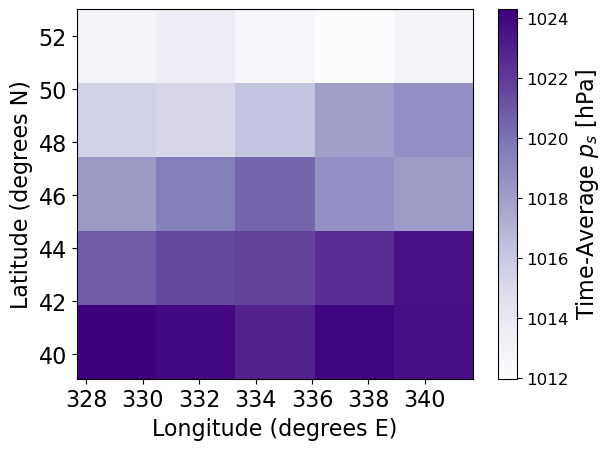

In [10]:
fig = da_ps_localized.mean(dim="time").plot(
    cmap = "Purples",
    cbar_kwargs = {"orientation": "vertical"},
)

plt.ylabel("Latitude (degrees N)", fontsize = "16")
plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)
plt.yticks(fontsize = 16, rotation = 0)

fig.colorbar.ax.tick_params(labelsize = 12)
fig.colorbar.set_label(label = r"Time-Average $p_s$ [hPa]", size = 16)

plt.show()

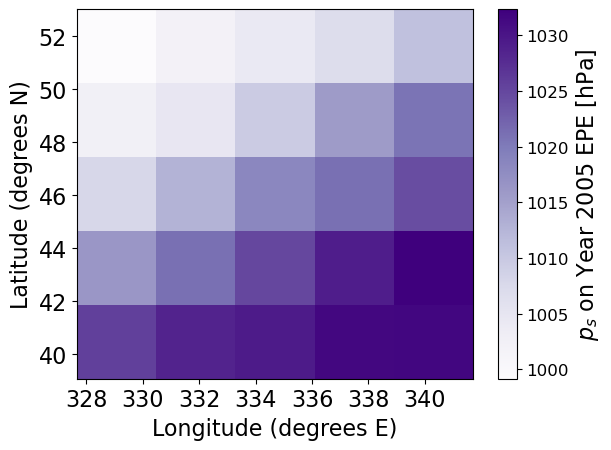

In [11]:
fig = da_ps_on_epe_days.sel(time = 2005).plot(
    cmap = "Purples",
    cbar_kwargs = {"orientation": "vertical"},
)

plt.ylabel("Latitude (degrees N)", fontsize = "16")
plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)
plt.yticks(fontsize = 16, rotation = 0)

fig.colorbar.ax.tick_params(labelsize = 12)
fig.colorbar.set_label(label = r"$p_s$ on Year 2005 EPE [hPa]", size = 16)

plt.title(None)

plt.show()

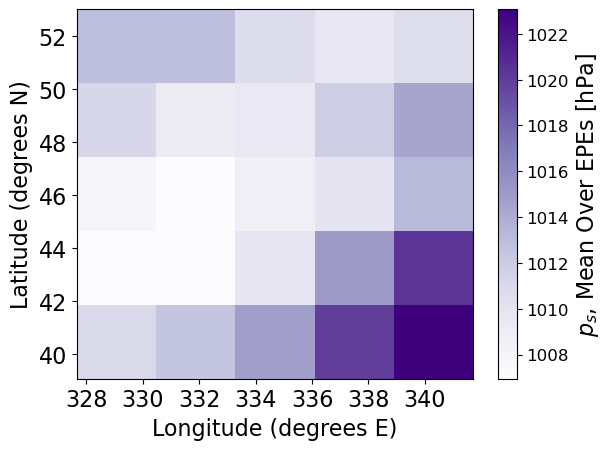

In [12]:
fig = da_ps_on_epe_days.mean(dim="time").plot(
    cmap = "Purples",
    cbar_kwargs={"orientation": "vertical",},
)

plt.ylabel("Latitude (degrees N)", fontsize = "16")
plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)
plt.yticks(fontsize = 16, rotation = 0)

fig.colorbar.ax.tick_params(labelsize = 12)
fig.colorbar.set_label(label = r"$p_s$, Mean Over EPEs [hPa]", size = 16)

plt.title(None)

plt.show()

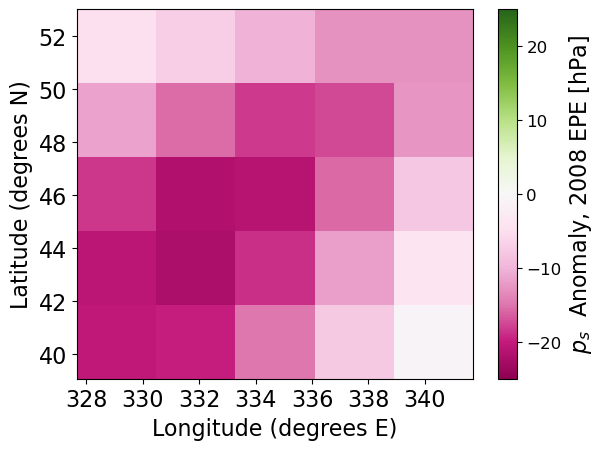

In [13]:
my_year = 2008
fig = (da_ps_on_epe_days.sel(time = my_year) - da_ps_localized.mean(dim="time")).plot(
    cmap = "PiYG",
    vmin = -25,
    vmax = 25,
    cbar_kwargs={"orientation": "vertical",},
)

plt.ylabel("Latitude (degrees N)", fontsize = "16")
plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)
plt.yticks(fontsize = 16, rotation = 0)

fig.colorbar.ax.tick_params(labelsize = 12)
fig.colorbar.set_label(label = f"$p_s$  Anomaly, {my_year} EPE [hPa]", size = 16)

plt.title(None)

plt.show()
plt.show()

In [14]:
da_ps_on_epe_days.sel(
    time = 2008,
    lat = random_lat,
    lon = random_lon,
    method = "nearest",
) - da_ps_on_epe_days.sel(
    time = 2008, 
    lat = random_lat - 2.5 ,
    lon = random_lon , 
    method = "nearest",
)

<xarray.DataArray ()> Size: 4B
array(-3.4682007, dtype=float32)
Coordinates:
    lon      float64 8B 334.7
    time     int64 8B 2008

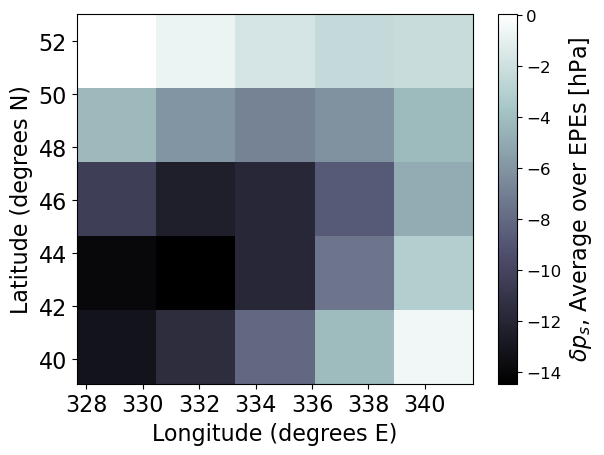

In [15]:
epe_anom = (da_ps_on_epe_days - da_ps_localized.mean(dim="time")).mean(dim="time")

vmin = epe_anom.min().values
vmax = epe_anom.max().values

fig = epe_anom.plot(
    cmap = "bone",
    cbar_kwargs={"orientation": "vertical"},
    vmin = vmin, 
    vmax = vmax,
)

plt.ylabel("Latitude (degrees N)", fontsize = "16")
plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)
plt.yticks(fontsize = 16, rotation = 0)

fig.colorbar.ax.tick_params(labelsize = 12)
fig.colorbar.set_label(label = r"$\delta p_s$, Average over EPEs [hPa]", size = 16)

plt.title(None)

plt.show()

In [16]:
(da_ps_on_epe_days - da_ps_localized.mean(dim="time")).mean(dim="time").min().values

array(-14.444672, dtype=float32)

In [17]:
(da_ps_on_epe_days.sel(
    lat = random_lat,
    lon = random_lon,
    method = "nearest",
) - da_ps_on_epe_days.sel(
    lat = random_lat + 2.5 ,
    lon = random_lon , 
    method = "nearest",
)).mean(
    dim = "time",
)

<xarray.DataArray ()> Size: 8B
array(-0.73427325)
Coordinates:
    lon      float64 8B 334.7

In [18]:
precip_threshold = 1.
da_ps_localized_clim_pdo = da_ps_localized.where(
    da_pr_localized.values > precip_threshold,
).mean(
    dim = "time",
    skipna = True,
)

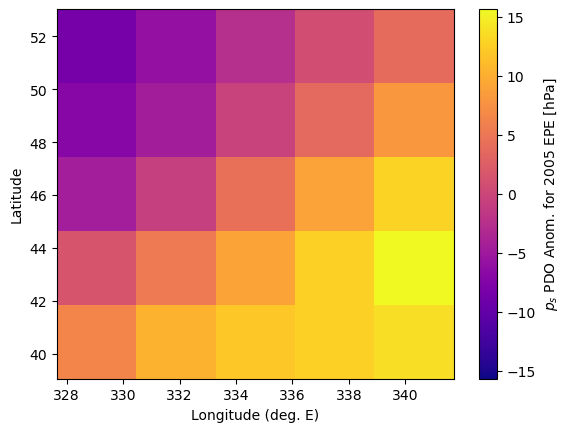

In [19]:
(da_ps_on_epe_days.sel(time = 2005) -  da_ps_localized_clim_pdo).plot(
    cmap = "plasma",
    cbar_kwargs={"label": r"$p_s$ PDO Anom. for 2005 EPE [hPa]",},
)
plt.ylabel("Latitude")
plt.xlabel("Longitude (deg. E)")
plt.title(None)
plt.show()

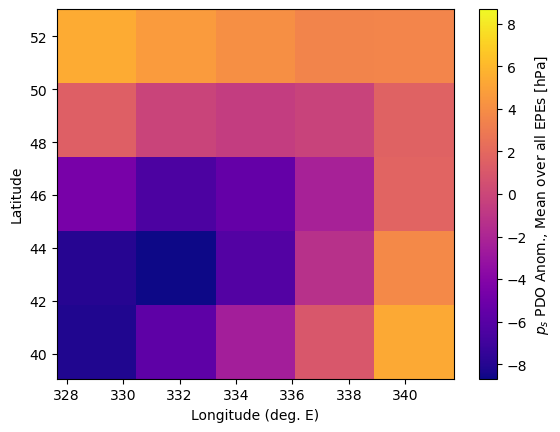

In [20]:
(da_ps_on_epe_days - da_ps_localized_clim_pdo).mean(dim = "time").plot(
    cmap = "plasma",
    cbar_kwargs={"label": r"$p_s$ PDO Anom., Mean over all EPEs [hPa]",},
)
plt.ylabel("Latitude")
plt.xlabel("Longitude (deg. E)")
plt.title(None)
plt.show()

In [21]:
da_ps_localized_wet_days = da_ps_localized.where(
    da_pr_localized.values > precip_threshold,
).dropna(dim="time")
da_ps_localized_dry_days = da_ps_localized.where(
    da_pr_localized.values <= precip_threshold,
).dropna(dim="time")

In [22]:
current_year = 2005
random_wet_time_index = rng.integers(
    low = 0, 
    high = len(select_fixed_year(da_ps_localized_wet_days, current_year).time), 
    size = 1,
)[0]
da_ps_localized_on_random_wet_day = select_fixed_year(da_ps_localized_wet_days, current_year).isel(time = random_wet_time_index)

random_dry_time_index = rng.integers(
    low = 0, 
    high = len(select_fixed_year(da_ps_localized_dry_days, current_year).time), 
    size = 1,
)[0]
da_ps_localized_on_random_dry_day = select_fixed_year(da_ps_localized_dry_days, current_year).isel(time = random_dry_time_index)

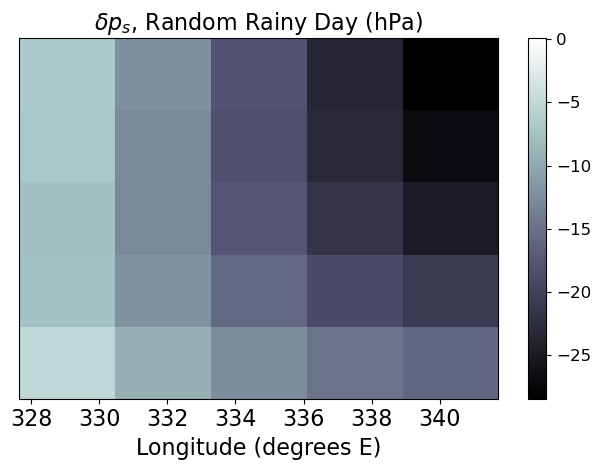

In [23]:
da_ps_localized_on_random_wet_day_anom_vanilla = da_ps_localized_on_random_wet_day - da_ps_localized.mean(dim="time")

vmin = min(
    da_ps_localized_on_random_wet_day_anom_vanilla.min().values,
    epe_anom.min().values,
)
vmax = max(
    da_ps_localized_on_random_wet_day_anom_vanilla.max().values,
    epe_anom.max().values,
)

fig = da_ps_localized_on_random_wet_day_anom_vanilla.plot(
    cmap = "bone",
    vmin = vmin,
    vmax = vmax,
    cbar_kwargs={"orientation": "vertical"},
)

#plt.ylabel("Latitude (degrees N)", fontsize = "16")
#plt.yticks(fontsize = 16, rotation = 0)

plt.tick_params(
    axis = "y",          
    which = 'both',      
    right = False,      
    left = False,
)
plt.yticks([])
plt.ylabel(None)

plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)

plt.title(r"$\delta p_s$, Random Rainy Day (hPa)", size = 16)

fig.colorbar.ax.tick_params(labelsize = 12)
fig.colorbar.set_label(label = None)

plt.tight_layout()

outfilename = "local_pressure_anomaly_random_wet_day"
plt.savefig("images/" + outfilename + ".png", dpi = 400)

plt.show()

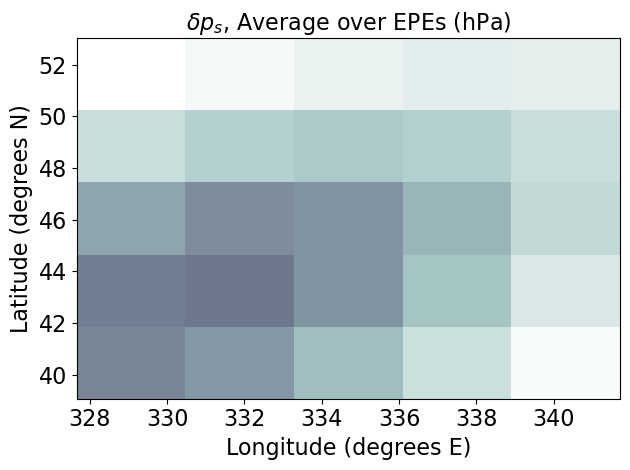

In [24]:
epe_anom = (da_ps_on_epe_days - da_ps_localized.mean(dim="time")).mean(dim="time")

fig = epe_anom.plot(
    cmap = "bone",
    add_colorbar = False,
    # cbar_kwargs={"orientation": "vertical"},
    vmin = vmin, 
    vmax = vmax,
)

plt.ylabel("Latitude (degrees N)", fontsize = "16")
plt.xlabel("Longitude (degrees E)", fontsize = "16")
plt.xticks(fontsize = 16, rotation = 0)
plt.yticks(fontsize = 16, rotation = 0)

plt.title(r"$\delta p_s$, Average over EPEs (hPa)", size = 16)

#fig.colorbar.ax.tick_params(labelsize = 12)
#fig.colorbar.set_label(label= None)

plt.tight_layout()

outfilename = "local_pressure_anomaly_epes"
plt.savefig("images/" + outfilename + ".png", dpi = 400)

plt.show()

In [25]:
da_ps_localized_on_random_wet_day.sel(
    lat = random_lat,
    lon = random_lon,
    method = "nearest",
).values - da_ps_localized_on_random_wet_day.sel(
    lat = random_lat + 2.5,
    lon = random_lon,
    method = "nearest",
).values

np.float32(5.0004272)

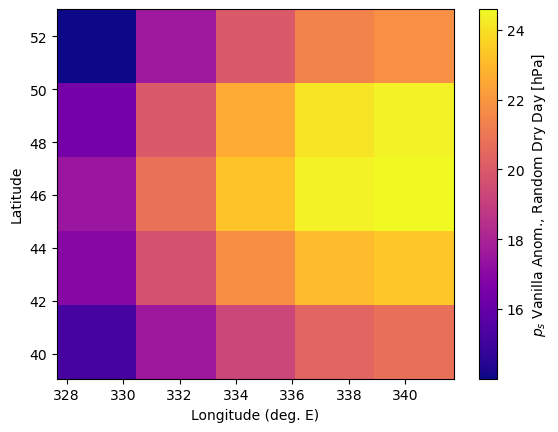

In [26]:
da_ps_localized_on_random_dry_day_anom_vanilla = da_ps_localized_on_random_dry_day - da_ps_localized.mean(dim="time")
da_ps_localized_on_random_dry_day_anom_vanilla.plot(
    cmap = "plasma",
    cbar_kwargs={"label": r"$p_s$ Vanilla Anom., Random Dry Day [hPa]",},
)
plt.ylabel("Latitude")
plt.xlabel("Longitude (deg. E)")
plt.title(None)
plt.show()

In [27]:
da_ps_localized_on_random_dry_day.sel(
    lat = random_lat,
    lon = random_lon,
    method = "nearest",
).values - da_ps_localized_on_random_dry_day.sel(
    lat = random_lat + 2.5,
    lon = random_lon,
    method = "nearest",
).values

np.float32(4.9779053)

Based on the experiments here, the issue appears to be that the $p_s$ anomaly typically doesn't change sign, *but* it does when an EPE is occurring! Thus $\nabla p_s$ can quickly change direction during an EPE. This is admittedly quite an interesting complement to my work on $|\nabla p_s|$ earlier ie. it suggests the orientation of this vector may have a part to play as well. 